# Description of CovDB

In [137]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

### Read in data

In [374]:
vp = pd.read_csv('../data/CoVDB/any_vp_var.csv')
cp = pd.read_csv('../data/CoVDB/any_cp_var.csv')

# Remove unicode characters (convert checkmark to True / False)
vp['Data Availability'] = (vp['Data Availability'] == u'\u2713') # <---- check mark symbol '✓'
cp['Data Availability'] = (cp['Data Availability'] == u'\u2713') # <---- check mark symbol '✓'

# Only keep columns for which Cmp is `=`, then drop `Cmp` columns
vp = vp[(vp[[col for col in vp.columns if 'Cmp' in col]]=='=').all(axis=1)]
cp = cp[(cp[[col for col in cp.columns if 'Cmp' in col]]=='=').all(axis=1)]
vp = vp[[col for col in vp.columns if 'Cmp' not in col]]
cp = cp[[col for col in cp.columns if 'Cmp' not in col]]

# Only keep rows where control is WuG (B.1)
vp = vp[vp['Control']=='Wild Type (B.1)']
cp = cp[cp['Control']=='Wild Type (B.1)']

# Subset to where num results = 1 or data availability = True
vp = vp[vp.apply(lambda x: x['# Results']==1 or x['Data Availability'], axis=1)]
cp = cp[cp.apply(lambda x: x['# Results']==1 or x['Data Availability'], axis=1)]

# Drop irrelevant columns
vp = vp.drop(columns=['Section', 'Fold Reduction: IQR25', 'Fold Reduction: IQR75'])
cp = cp.drop(columns=['Section', 'Fold Reduction: IQR25', 'Fold Reduction: IQR75'])

In [375]:
# Summarize columns
vpcols = set(vp.columns)
cpcols = set(cp.columns)
print('Common columns:')
for c in vpcols.intersection(cpcols):
    print(f'\t{c}')
print()
print('Vaccine plasma only columns:')
for c in vpcols - cpcols:
    print(f'\t{c}')
print()
print('Convalescent plasma only columns:')
for c in cpcols - vpcols:
    print(f'\t{c}')

Common columns:
	Fold Reduction: Median
	Months
	Control: NT50 GeoMean
	# Results
	Control
	Data Availability
	Variant: Mutations
	Assay
	Control: NT50 GSD
	Reference: DOI
	Reference
	Variant
	Variant: Pos
	Potency: NT50 GSD
	Potency: NT50 GeoMean

Vaccine plasma only columns:
	# Shots
	Pre-vaccine Infection
	Vaccine

Convalescent plasma only columns:
	Infection (CP)


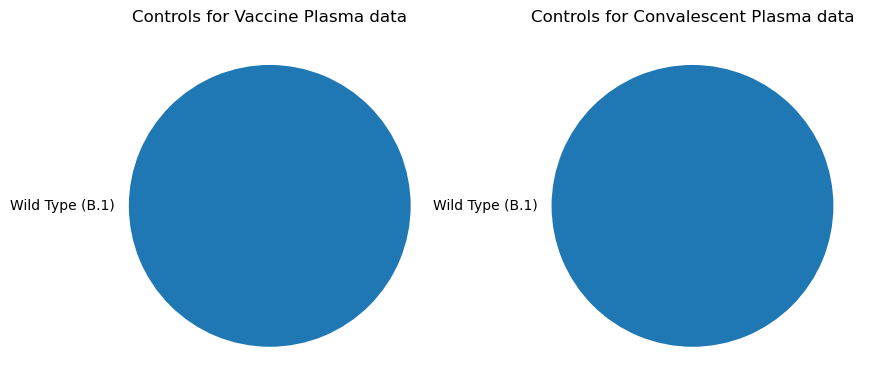

In [376]:
# What are the different controls?
vpcontrols = vp[['Control', '# Results']].groupby('Control').agg('sum').sort_values(by='# Results', ascending=False).reset_index()
cpcontrols = cp[['Control', '# Results']].groupby('Control').agg('sum').sort_values(by='# Results', ascending=False).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].pie(vpcontrols['# Results'].values, labels=vpcontrols['Control'].values);
axes[0].set_title('Controls for Vaccine Plasma data');
axes[1].pie(cpcontrols['# Results'].values, labels=cpcontrols['Control'].values);
axes[1].set_title('Controls for Convalescent Plasma data');

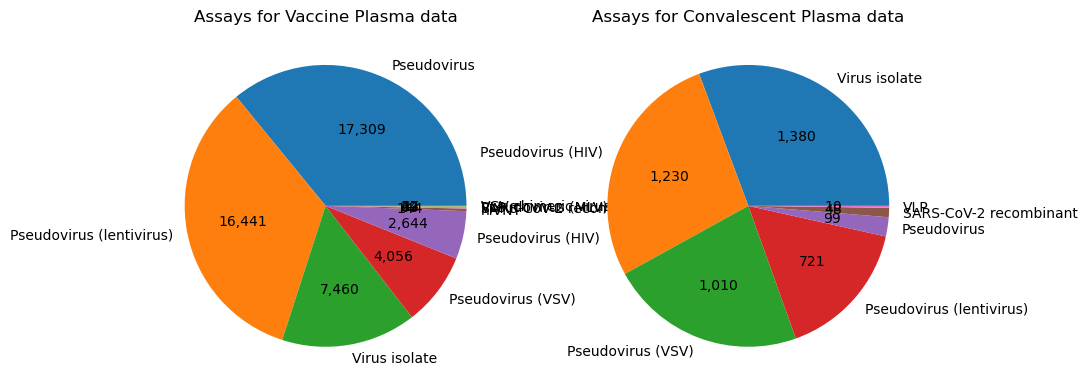

In [377]:
# What are the different assays?
vpcontrols = vp[['Assay', '# Results']].groupby('Assay').agg('sum').sort_values(by='# Results', ascending=False).reset_index()
cpcontrols = cp[['Assay', '# Results']].groupby('Assay').agg('sum').sort_values(by='# Results', ascending=False).reset_index()

def count(pct, data):
    total_count = data['# Results'].sum()
    x = int(np.round(pct/100*total_count))
    return '{:,.0f}'.format(x)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].pie(vpcontrols['# Results'].values, labels=vpcontrols['Assay'].values, autopct=lambda pct: count(pct, vpcontrols));
axes[0].set_title('Assays for Vaccine Plasma data');
axes[1].pie(cpcontrols['# Results'].values, labels=cpcontrols['Assay'].values, autopct=lambda pct: count(pct, cpcontrols));
axes[1].set_title('Assays for Convalescent Plasma data');

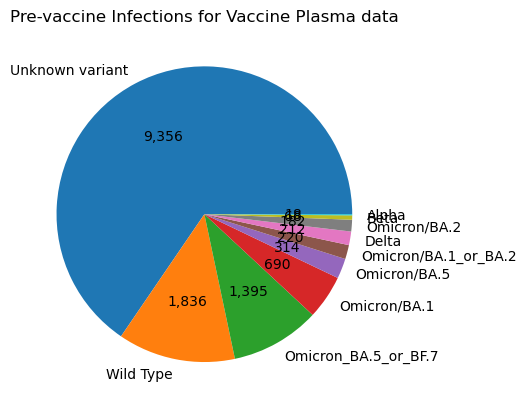

In [378]:
# What are the pre-vaccine infections?
vp_infections = vp[['Pre-vaccine Infection', '# Results']].groupby('Pre-vaccine Infection').agg('sum').sort_values(by='# Results', ascending=False).reset_index()

def count(pct, data):
    total_count = data['# Results'].sum()
    x = int(np.round(pct/100*total_count))
    return '{:,.0f}'.format(x)
    

fig, ax = plt.subplots()
ax.pie(vp_infections['# Results'].values, 
       labels=vp_infections['Pre-vaccine Infection'].values, 
       autopct=lambda pct: count(pct, vp_infections)
      );
ax.set_title('Pre-vaccine Infections for Vaccine Plasma data');

### How are number of results per study distributed?

In [379]:
vp_study_vars = vp[['Reference', 'Reference: DOI', 'Variant: Mutations']].groupby(['Reference', 'Reference: DOI']).agg('nunique').reset_index().rename(columns={'Variant: Mutations':'# Strains'})
vp_study_results = vp[['Reference', 'Reference: DOI', '# Results']].groupby(['Reference', 'Reference: DOI']).agg('sum').reset_index()
vp_study = pd.merge(vp_study_vars, vp_study_results, on=['Reference', 'Reference: DOI'])
vp_study = vp_study.sort_values(by='# Results', ascending=False)

vp_study

,Reference,Reference: DOI,# Strains,# Results
11,Branche23b,10.1038/s41591-023-02503-4,11,12342
18,Chalkias22,10.21203/rs.3.rs-1555201/v1,3,8286
9,Branche22,10.1101/2022.07.12.22277336,3,3603
10,Branche23,10.1093/cid/ciad209,5,2576
34,Filardi23,10.1126/scitranslmed.ade6023,5,2170
...,...,...,...,...
111,Wang22,10.1080/22221751.2022.2030200,1,10
43,Ikemura21,10.1101/2021.12.13.21267761,1,8
8,Becker21,10.1038/s41467-021-23473-6,1,7
37,Greaney21c,10.1126/scitranslmed.abi9915,1,6


In [380]:
cp_study_vars = cp[['Reference', 'Reference: DOI', 'Variant: Mutations']].groupby(['Reference', 'Reference: DOI']).agg('nunique').reset_index().rename(columns={'Variant: Mutations':'# Strains'})
cp_study_results = cp[['Reference', 'Reference: DOI', '# Results']].groupby(['Reference', 'Reference: DOI']).agg('sum').reset_index()
cp_study = pd.merge(cp_study_vars, cp_study_results, on=['Reference', 'Reference: DOI'])
cp_study = cp_study.sort_values(by='# Results', ascending=False)

cp_study

,Reference,Reference: DOI,# Strains,# Results
65,Wratil22,10.1038/s41591-022-01715-4,5,478
7,Cantoni21,10.3389/fimmu.2022.773982,7,427
68,Yisimayi23,10.1101/2023.05.01.538516,12,288
27,Li21c,10.1016/j.cell.2021.02.042,6,265
25,Kurahashi22,10.1093/infdis/jiac178,2,213
...,...,...,...,...
61,Weigang21,10.1038/s41467-021-26602-3,6,6
4,Becker21,10.1038/s41467-021-23473-6,1,6
16,Greaney21c,10.1126/scitranslmed.abi9915,1,6
24,Kemp21,10.1038/s41586-021-03291-y,1,3


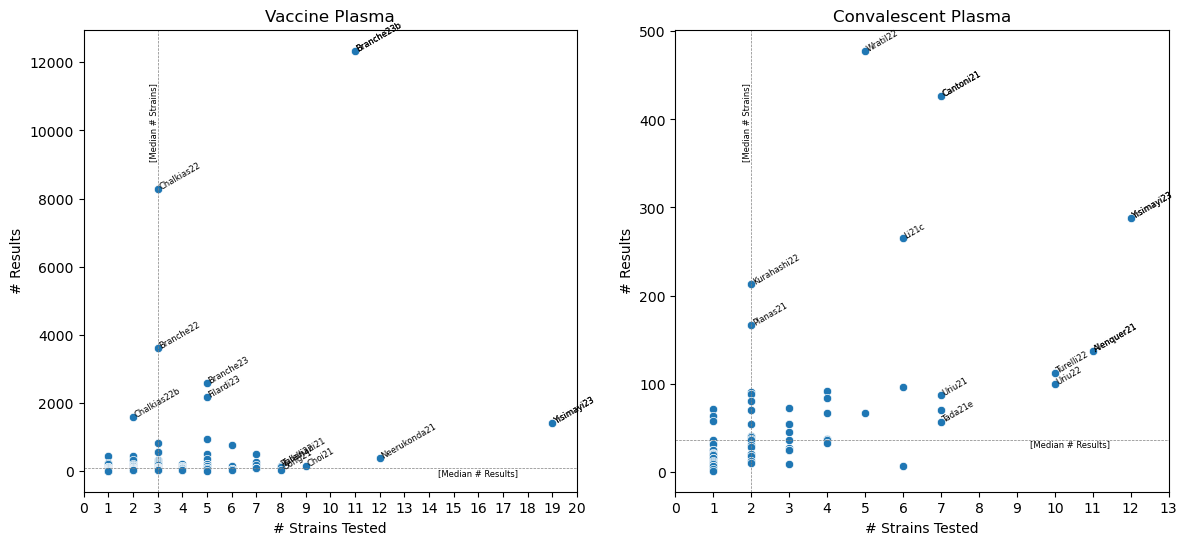

In [381]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].set_title('Vaccine Plasma')
axes[1].set_title('Convalescent Plasma')

for df, ax in zip([vp_study, cp_study], axes):
    
    sns.scatterplot(x='# Strains',
                    y='# Results',
                    data=df,
                    ax=ax)

    ax.set_xticks(range(df['# Strains'].max()+2))
    ax.set_xticklabels([i for i in range(df['# Strains'].max()+2)]);
    ax.set_xlabel('# Strains Tested')
    
    
    top_n = 7
    for i in range(top_n):
        # Strains
        row = df.sort_values(by='# Strains', ascending=False).iloc[i]
        ax.text(row['# Strains'], row['# Results'], row['Reference'], fontsize=6, rotation=30)
        # Results
        row = df.sort_values(by='# Results', ascending=False).iloc[i]
        ax.text(row['# Strains'], row['# Results'], row['Reference'], fontsize=6, rotation=30)
        
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    p = 0.8
    strain_median = df['# Strains'].median(); ax.vlines(strain_median, ylim[0], ylim[1], linestyle='--', linewidth=0.5, color='gray')
    result_median = df['# Results'].median(); ax.hlines(result_median, xlim[0], xlim[1], linestyle='--', linewidth=0.5, color='gray')
    ax.text(strain_median, p*ylim[1]+(1-p)*ylim[0], '[Median # Strains]', fontsize=6, rotation=90, ha='right', va='center')
    ax.text(p*xlim[1]+(1-p)*xlim[0], result_median, '[Median # Results]', fontsize=6, ha='center', va='top')
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    
    

From the figures above, it seems the best way to optimize is to grab the references with the most number of strains tested. Of these, take those with the highest number of results. We can arbitrarily set a cutoff of how many references we are willing to manually go through, maybe 20 references for each type (VP and CP).

In [370]:
# Get the list of references to pull
n = 10

# Vaccine plasma first
print('{:20s}\t{:20s}'.format('Reference', 'Reference: DOI'))
print('-'*55)
result_count = 0
strain_set = set()
for i in range(n):
    row = vp_study.sort_values(by=['# Strains', '# Results'], ascending=False).iloc[i]
    result_count += row['# Results']
    muts = set(vp[vp['Reference']==row['Reference']]['Variant: Mutations'].apply(lambda x: tuple(sorted(x.split(' + ')))).values.tolist())
    strain_set = strain_set.union(muts)
    print('{:20s}\tDOI: {:20s}'.format(row['Reference'], row['Reference: DOI']))
    
print('Total number of results:', result_count)
print('Total number of strains:', len(strain_set))


print()
print()

n = 15

# Conv plasma second
print('{:20s}\t{:20s}'.format('Reference', 'Reference: DOI'))
print('-'*55)
result_count = 0
strain_set = set()
for i in range(n):
    row = cp_study.sort_values(by=['# Strains', '# Results'], ascending=False).iloc[i]
    result_count += row['# Results']
    muts = set(cp[cp['Reference']==row['Reference']]['Variant: Mutations'].apply(lambda x: tuple(sorted(x.split(' + ')))).values.tolist())
    strain_set = strain_set.union(muts)
    print('{:20s}\tDOI: {:20s}'.format(row['Reference'], row['Reference: DOI']))
    
print('Total number of results:', result_count)
print('Total number of strains:', len(strain_set))

Reference           	Reference: DOI      
-------------------------------------------------------
Yisimayi23          	DOI: 10.1101/2023.05.01.538516
Neerukonda21        	DOI: 10.3390/v13122485   
Branche23b          	DOI: 10.1038/s41591-023-02503-4
Choi21              	DOI: 10.1128/JVI.01313-21
Turelli22           	DOI: 10.1101/2022.05.02.22274436
Valleriani21        	DOI: 10.3390/v13102011   
Gong21              	DOI: 10.1016/j.virol.2021.09.001
Jacobsen22          	DOI: 10.1038/s41598-022-22552-y
Tada21e             	DOI: 10.3389/fimmu.2022.797589
Uriu23              	DOI: 10.1016/S1473-3099(23)00051-8
Total number of results: 15511
Total number of strains: 64


Reference           	Reference: DOI      
-------------------------------------------------------
Yisimayi23          	DOI: 10.1101/2023.05.01.538516
Alenquer21          	DOI: 10.1371/journal.ppat.1009772
Turelli22           	DOI: 10.1101/2022.05.02.22274436
Uriu22              	DOI: 10.1093/infdis/jiac053
Cantoni21         

In [367]:
vp[vp['Reference']=='Yisimayi23']

,Reference,Reference: DOI,Assay,Pre-vaccine Infection,Vaccine,# Shots,Months,Control,Control: NT50 GeoMean,Control: NT50 GSD,Variant,Variant: Pos,Variant: Mutations,# Results,Potency: NT50 GeoMean,Potency: NT50 GSD,Fold Reduction: Median,Data Availability
916,Yisimayi23,10.1101/2023.05.01.538516,Pseudovirus (VSV),Omicron_BA.5_or_BF.7,CoronaVac,3,≥6m,Wild Type (B.1),354.8,2.8,Omicron/BQ.1.18,19,T19I + L24S + Δ25-27 + Δ69-70 + G142D + Δ144 +...,90,114.0,2.2,3.3,True
1064,Yisimayi23,10.1101/2023.05.01.538516,Pseudovirus (VSV),Omicron_BA.5_or_BF.7,CoronaVac,3,≥6m,Wild Type (B.1),354.8,2.8,Omicron/BQ.1.1,19,T19I + L24S + Δ25-27 + Δ69-70 + G142D + V213G ...,90,152.7,2.6,2.8,True
1202,Yisimayi23,10.1101/2023.05.01.538516,Pseudovirus (VSV),Omicron_BA.5_or_BF.7,CoronaVac,3,≥6m,Wild Type (B.1),354.8,2.8,Omicron/BF.7,19,T19I + L24S + Δ25-27 + Δ69-70 + G142D + V213G ...,90,256.7,3.2,1.5,True
1787,Yisimayi23,10.1101/2023.05.01.538516,Pseudovirus (VSV),Omicron_BA.5_or_BF.7,CoronaVac,3,≥6m,Wild Type (B.1),354.8,2.8,Omicron/BA.5,19,T19I + L24S + Δ25-27 + Δ69-70 + G142D + V213G ...,90,331.4,3.2,1.1,True
1908,Yisimayi23,10.1101/2023.05.01.538516,Pseudovirus (VSV),Omicron_BA.5_or_BF.7,CoronaVac,3,≥6m,Wild Type (B.1),354.8,2.8,Omicron/XBB.1.16,19,T19I + L24S + Δ25-27 + V83A + G142D + Δ144 + H...,90,97.2,2.1,3.9,True
1909,Yisimayi23,10.1101/2023.05.01.538516,Pseudovirus (VSV),Omicron_BA.5_or_BF.7,CoronaVac,3,≥6m,Wild Type (B.1),998.4,1.1,Omicron/XBB.1.5/K478R/F456L/H505Y/R403K/K444T/...,19,T19I + L24S + Δ25-27 + V83A + G142D + Δ144 + H...,45,33.1,1.0,31.9,True
1910,Yisimayi23,10.1101/2023.05.01.538516,Pseudovirus (VSV),Omicron_BA.5_or_BF.7,CoronaVac,3,≥6m,Wild Type (B.1),998.4,1.1,Omicron/XBB.1.5/K478R/F456L/H505Y/R403K/K444T,19,T19I + L24S + Δ25-27 + V83A + G142D + Δ144 + H...,45,67.3,1.2,15.8,True
1911,Yisimayi23,10.1101/2023.05.01.538516,Pseudovirus (VSV),Omicron_BA.5_or_BF.7,CoronaVac,3,≥6m,Wild Type (B.1),998.4,1.1,Omicron/XBB.1.5/K478R/F456L/H505Y/R403K,19,T19I + L24S + Δ25-27 + V83A + G142D + Δ144 + H...,45,99.1,1.4,12.2,True
1912,Yisimayi23,10.1101/2023.05.01.538516,Pseudovirus (VSV),Omicron_BA.5_or_BF.7,CoronaVac,3,≥6m,Wild Type (B.1),998.4,1.1,Omicron/XBB.1.5/K478R/F456L/H505Y/R403K/K444T/...,19,T19I + L24S + Δ25-27 + V83A + G142D + Δ144 + H...,45,38.1,1.0,27.8,True
1913,Yisimayi23,10.1101/2023.05.01.538516,Pseudovirus (VSV),Omicron_BA.5_or_BF.7,CoronaVac,3,≥6m,Wild Type (B.1),998.4,1.1,Omicron/XBB.1.5/K478R/F456L/H505Y/R403K/K444T/...,19,T19I + L24S + Δ25-27 + V83A + G142D + Δ144 + H...,45,46.5,1.1,21.7,True


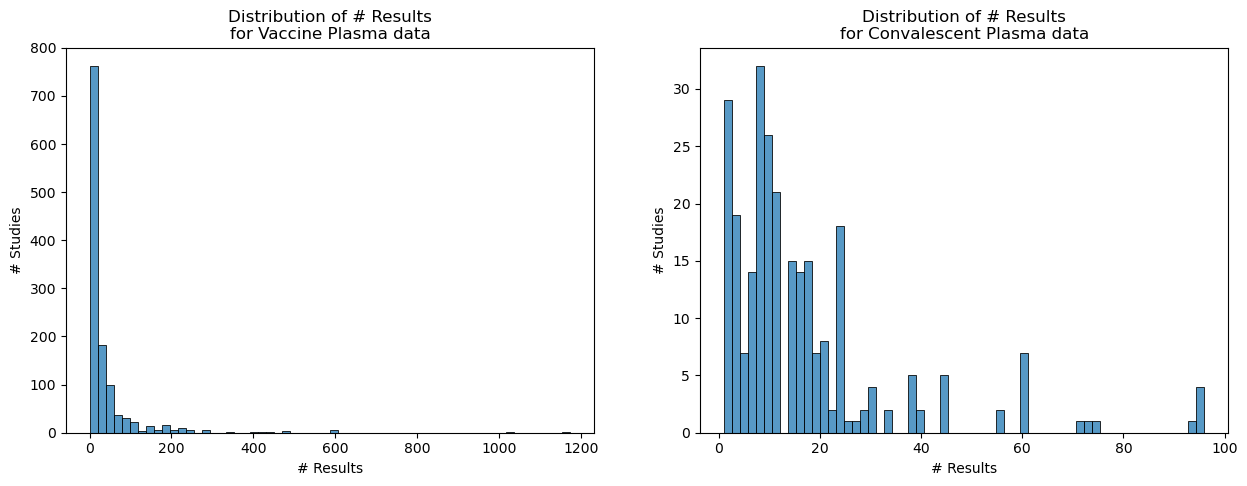

In [248]:
fig, axes = plt.subplots(1,2, figsize=(15, 5))
sns.histplot(x='# Results',
             data=vp,
             bins=60,
             ax=axes[0])
sns.histplot(x='# Results',
             data=cp,
             bins=60,
             ax=axes[1])
axes[0].set_ylabel('# Studies')
axes[1].set_ylabel('# Studies')
axes[0].set_title('Distribution of # Results\nfor Vaccine Plasma data');
axes[1].set_title('Distribution of # Results\nfor Convalescent Plasma data');

In [249]:
vp_num_ones = (vp['# Results']==1).sum()
cp_num_ones = (cp['# Results']==1).sum()
print(f'There are {vp_num_ones} Vaccine Plasma studies with only one result')
print(f'There are {cp_num_ones} Convalescent Plasma studies with only one result')

There are 117 Vaccine Plasma studies with only one result
There are 8 Convalescent Plasma studies with only one result


### Look at studies with the most number of results

In [250]:
vp.sort_values(by='# Results', ascending=False).head(10)

,Reference,Reference: DOI,Assay,Pre-vaccine Infection,Vaccine,# Shots,Months,Control,Control: NT50 GeoMean,Control: NT50 GSD,Variant,Variant: Pos,Variant: Mutations,# Results,Potency: NT50 GeoMean,Potency: NT50 GSD,Fold Reduction: Median,Data Availability
679,Chalkias22,10.21203/rs.3.rs-1555201/v1,Pseudovirus (lentivirus),NaN,mRNA-1273 + mRNA-1273.211,3,1m,Wild Type (B.1),3155.4,1.4,Beta,18,L18F + D80A + D215G + Δ242-244 + R246I + K417N...,1174,1318.8,1.2,2.7,True
678,Chalkias22,10.21203/rs.3.rs-1555201/v1,Pseudovirus (lentivirus),NaN,mRNA-1273 + mRNA-1273.211,3,≥6m,Wild Type (B.1),1229.7,1.2,Beta,18,L18F + D80A + D215G + Δ242-244 + R246I + K417N...,1174,371.9,1.1,3.6,True
677,Chalkias22,10.21203/rs.3.rs-1555201/v1,Pseudovirus (lentivirus),NaN,mRNA-1273,2,≥6m,Wild Type (B.1),106.6,1.1,Beta,18,L18F + D80A + D215G + Δ242-244 + R246I + K417N...,1018,26.2,1.2,4.2,True
4614,Chalkias22b,10.1056/NEJMoa2208343,Pseudovirus (lentivirus),NaN,mRNA-1273,3,2-6m,Wild Type (B.1),1372.5,1.1,Omicron/BA.1,67,A67V + Δ69-70 + T95I + G142D + Δ143-145 + N211...,594,312.4,1.1,4.6,True
1655,Chalkias22b,10.1056/NEJMoa2208343,Pseudovirus (lentivirus),NaN,mRNA-1273,3,2-6m,Wild Type (B.1),1372.5,1.1,Omicron/BA.5,19,T19I + L24S + Δ25-27 + Δ69-70 + G142D + V213G ...,594,126.0,1.1,10.9,True
4605,Chalkias22,10.21203/rs.3.rs-1555201/v1,Pseudovirus (lentivirus),NaN,mRNA-1273 + mRNA-1273.211,3,1m,Wild Type (B.1),2224.4,1.0,Omicron/BA.1,67,A67V + Δ69-70 + T95I + G142D + Δ143-145 + N211...,592,1398.9,1.0,1.6,True
3585,Chalkias22,10.21203/rs.3.rs-1555201/v1,Pseudovirus (lentivirus),NaN,mRNA-1273 + mRNA-1273.211,3,1m,Wild Type (B.1),2224.4,1.0,Delta,19,T19R + G142D + E156G + Δ157-158 + L452R + T478...,592,1494.0,1.0,1.5,True
4609,Chalkias22,10.21203/rs.3.rs-1555201/v1,Pseudovirus (lentivirus),NaN,mRNA-1273 + mRNA-1273.211,3,≥6m,Wild Type (B.1),1022.9,1.0,Omicron/BA.1,67,A67V + Δ69-70 + T95I + G142D + Δ143-145 + N211...,592,314.9,1.0,3.3,True
3589,Chalkias22,10.21203/rs.3.rs-1555201/v1,Pseudovirus (lentivirus),NaN,mRNA-1273 + mRNA-1273.211,3,≥6m,Wild Type (B.1),1022.9,1.0,Delta,19,T19R + G142D + E156G + Δ157-158 + L452R + T478...,592,495.1,1.0,2.1,True
3909,Branche23b,10.1038/s41591-023-02503-4,Pseudovirus,NaN,mRNA-1273.351_529_bivalent,4,1m,Wild Type (B.1),8206.4,2.1,Delta,19,T19R + E156G + Δ157-158 + L452R + T478K + P681...,471,4501.2,2.4,1.9,True


In [251]:
cp.sort_values(by='# Results', ascending=False).head(10)

,Reference,Reference: DOI,Assay,Infection (CP),Months,Control,Control: NT50 GeoMean,Control: NT50 GSD,Variant,Variant: Pos,Variant: Mutations,# Results,Potency: NT50 GeoMean,Potency: NT50 GSD,Fold Reduction: Median,Data Availability
121,Wratil22,10.1038/s41591-022-01715-4,Virus isolate,Wild Type,≥6m,Wild Type (B.1),475.3,8.6,Gamma,18,L18F + T20N + P26S + D138Y + R190S + K417T + E...,96,257.7,7.8,1.9,True
621,Wratil22,10.1038/s41591-022-01715-4,Virus isolate,Wild Type,≥6m,Wild Type (B.1),475.3,8.6,Delta,19,T19R + E156G + Δ157-158 + S221L + L452R + T478...,96,196.9,9.4,1.8,True
920,Wratil22,10.1038/s41591-022-01715-4,Virus isolate,Wild Type,≥6m,Wild Type (B.1),475.3,8.6,Beta,69,H69H + H69R + D80A + D215G + K417K + K417N + A...,96,111.0,11.7,2.5,True
1103,Wratil22,10.1038/s41591-022-01715-4,Virus isolate,Wild Type,≥6m,Wild Type (B.1),475.3,8.6,Alpha,69,Δ69 + G72R + Δ144 + N501Y + A570D + P681H + T7...,96,301.8,10.9,1.4,True
901,Wratil22,10.1038/s41591-022-01715-4,Virus isolate,Wild Type,≥6m,Wild Type (B.1),473.2,8.7,Omicron/BA.1,67,A67V + Δ69-70 + T95I + G142D + Δ143-145 + N211...,94,44.3,8.6,7.4,True
325,Li21c,10.1016/j.cell.2021.02.042,Pseudovirus (VSV),Wild Type,2-6m,Wild Type (B.1),1303.0,2.1,Beta,(Various),(Various),75,518.8,4.0,2.7,True
596,Kurahashi22,10.1093/infdis/jiac178,Virus isolate,Wild Type,2-6m,Wild Type (B.1),20.0,2.7,Delta,19,T19R + G142D + Δ156-157 + R158G + L452R + T478...,73,8.4,2.7,2.9,True
846,Kurahashi22,10.1093/infdis/jiac178,Virus isolate,Wild Type,2-6m,Wild Type (B.1),20.0,2.7,Omicron/BA.1,67,A67V + Δ69-70 + T95I + G142D + Δ143-145 + N211...,72,1.5,1.9,14.5,True
1091,Cantoni21,10.3389/fimmu.2022.773982,Pseudovirus (HIV),Wild Type,1m,Wild Type (B.1),318.9,4.0,B.1.1.298,69,Δ69-70 + Y453F + I692V + M1229I,61,279.4,3.6,1.3,True
975,Cantoni21,10.3389/fimmu.2022.773982,Pseudovirus (HIV),Wild Type,1m,Wild Type (B.1),318.9,4.0,Alpha,69,Δ69-70 + Δ141 + Δ144-145 + N501Y + A570D + P68...,61,89.0,8.7,2.0,True
